# 26 · `climatology`

`temporal.Climatology` groups the time series by a periodic label and plots the group means with a min/max spread plume.

**Setup** — inline plots and the path to the bundled Lisbon DEM.

In [1]:
%matplotlib inline
from pathlib import Path

# Locate the bundled Lisbon DEM from the repo root (works from docs/ or the repo root).
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
from pyramids.dataset import Dataset, GeoReference
from digitalearth.scene import Map
ds = Dataset.read_file(DEM)
import numpy as np
from pyramids.dataset.collection import DatasetCollection
z = np.nan_to_num(ds.read_array(band=0).astype('float32'))
rng = np.random.default_rng(0)
ref = GeoReference(geo=ds.geotransform, epsg=ds.epsg)
members = [Dataset.from_array(arr=(z * f + rng.normal(0, 4, z.shape)).astype('float32'), geo_ref=ref)
           for f in np.linspace(0.4, 1.0, 8)]
dc = DatasetCollection(members[0], len(members), datasets=members)
from digitalearth.temporal import Climatology
import matplotlib.pyplot as plt

Group the 8 steps into 4 seasons and plot the climatology.

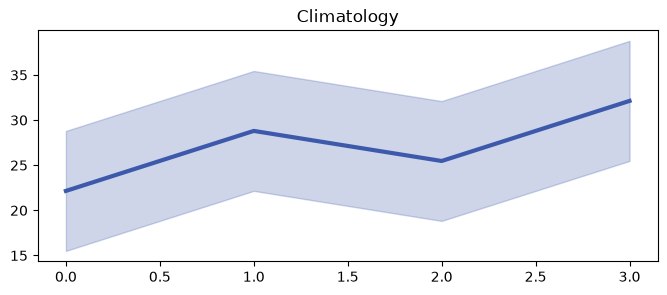

In [2]:
labels = ['DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM', 'JJA', 'SON']
fig, ax = plt.subplots(figsize=(8, 3))
Climatology(dc, labels).plot(ax=ax)
ax.set_title('Climatology')
fig;